In [2]:
# PART 1, STEP 1: Dataset Verification
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("kaushil268/disease-prediction-using-machine-learning")
df = pd.read_csv(os.path.join(path, "Training.csv"))

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nTarget variable (prognosis):")
print("Number of unique diseases:", df['prognosis'].nunique())
print("Sample diseases:", df['prognosis'].unique()[:10])

print("\nFeatures (symptoms):")
print("Number of symptom columns:", len(df.columns) - 1)
print("All symptoms are 0 or 1:", df.drop('prognosis', axis=1).isin([0,1]).all().all())

print("\nMissing values:", df.isnull().sum().sum())

df['symptom_count'] = df.drop('prognosis', axis=1).sum(axis=1)
print("\nRegression target (symptom count):")
print("Min symptoms:", df['symptom_count'].min())
print("Max symptoms:", df['symptom_count'].max())
print("Average symptoms:", df['symptom_count'].mean())

Using Colab cache for faster access to the 'disease-prediction-using-machine-learning' dataset.
Dataset shape: (4920, 134)

First 5 rows:
   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  scurring  \
0       0           0             0        0                 0  ...         0   
1       0           0             0        0                 0  ...         0   
2       0           0             0        0                 0  ...         0   
3       0           0             0        0                 0 

Step 1 Reflection:

Problem Statement:
Our group aims to build an AI system that can help with medical diagnosis by:

Predicting diseases based on patient symptoms (classification task)

Estimating disease severity based on symptom count (regression task)

Dataset Description:
The dataset contains 4920 patient records with 133 symptoms (binary: 0=not present, 1=present) and 41 different diseases. Each row represents a patient with their symptoms and final diagnosis.

Dataset Suitability:

For classification: The dataset has 41 distinct disease classes, making it suitable for multi-class classification

For regression: We created a symptom count feature (0-21 symptoms) that serves as a severity score, suitable for regression

The dataset is clean with no missing values and all features are already numerical (0/1)

In [40]:
# PART 1, STEP 2: Data Splitting and Preprocessing
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset
path = kagglehub.dataset_download("kaushil268/disease-prediction-using-machine-learning")
df = pd.read_csv(os.path.join(path, "Training.csv"))

# Drop the 'Unnamed: 133' column as it contains only NaN values
df = df.drop(columns=['Unnamed: 133'], errors='ignore')

# Create regression target (symptom count)
df['symptom_count'] = df.drop('prognosis', axis=1).sum(axis=1)

# Separate features and targets
X = df.drop(['prognosis', 'symptom_count'], axis=1)
y_class = df['prognosis']  # for classification
y_reg = df['symptom_count']  # for regression

print("Features shape:", X.shape)
print("Classification target shape:", y_class.shape)
print("Regression target shape:", y_reg.shape)

Using Colab cache for faster access to the 'disease-prediction-using-machine-learning' dataset.
Features shape: (4920, 132)
Classification target shape: (4920,)
Regression target shape: (4920,)


In [4]:
# Split data: 80% train, 10% validation, 10% test
X_train, X_temp, y_class_train, y_class_temp, y_reg_train, y_reg_temp = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

X_val, X_test, y_class_val, y_class_test, y_reg_val, y_reg_test = train_test_split(
    X_temp, y_class_temp, y_reg_temp, test_size=0.5, random_state=42, stratify=y_class_temp
)

print("\nTraining set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))
print("Training set percentage:", len(X_train)/len(X)*100, "%")


Training set size: 3936
Validation set size: 492
Test set size: 492
Training set percentage: 80.0 %


In [7]:
# Check class distribution in each split
print("\nClass distribution in training (first 5 diseases):")
print(y_class_train.value_counts(normalize=True).head())
print("\nClass distribution in validation (first 5 diseases):")
print(y_class_val.value_counts(normalize=True).head())
print("\nClass distribution in test (first 5 diseases):")
print(y_class_test.value_counts(normalize=True).head())


Class distribution in training (first 5 diseases):
prognosis
Cervical spondylosis    0.02439
Hepatitis B             0.02439
Jaundice                0.02439
Chicken pox             0.02439
Osteoarthristis         0.02439
Name: proportion, dtype: float64

Class distribution in validation (first 5 diseases):
prognosis
Allergy        0.02439
Hepatitis E    0.02439
Typhoid        0.02439
Malaria        0.02439
AIDS           0.02439
Name: proportion, dtype: float64

Class distribution in test (first 5 diseases):
prognosis
Tuberculosis            0.02439
Allergy                 0.02439
Cervical spondylosis    0.02439
Hyperthyroidism         0.02439
Jaundice                0.02439
Name: proportion, dtype: float64


In [8]:
# Preprocessing: Scale the features
scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train)

# Transform all datasets
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

print("\nAfter scaling:")
print("Training set mean (first 5 features):", X_train_scaled.iloc[:,:5].mean().values.round(2))
print("Training set std (first 5 features):", X_train_scaled.iloc[:,:5].std().values.round(2))
print("Validation set mean:", X_val_scaled.iloc[:,:5].mean().values.round(2))
print("Test set mean:", X_test_scaled.iloc[:,:5].mean().values.round(2))


After scaling:
Training set mean (first 5 features): [-0. -0.  0.  0. -0.]
Training set std (first 5 features): [1. 1. 1. 1. 1.]
Validation set mean: [ 0.01  0.01 -0.    0.01  0.02]
Test set mean: [ 0.   -0.01 -0.03 -0.   -0.01]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Step 2 Reflection:

Data Splitting Strategy:

Used stratified random split to maintain the same disease distribution across all sets

Split ratio: 80% training, 10% validation, 10% test

Validation set helps tune models without touching test data

Test set remains untouched until final evaluation

Preprocessing Steps:

Feature Scaling: Applied StandardScaler to normalize all features (mean=0, std=1)

Justification: Many ML algorithms perform better with scaled features

Important for distance-based models like k-NN and SVM

No missing values: Dataset is clean, no imputation needed

No encoding needed: All features are already numerical (0/1)

Why scaling on training data only?

Fitted scaler on training data only to prevent data leakage

Applied same transformation to validation and test sets

In [10]:
# PART 1, STEP 3: Linear Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Check for NaN values
print("Checking for NaN values...")
print("Training data NaN count:", X_train_scaled.isna().sum().sum())
print("Validation data NaN count:", X_val_scaled.isna().sum().sum())
print("Test data NaN count:", X_test_scaled.isna().sum().sum())

# Check for infinite values
print("\nChecking for infinite values...")
print("Training data inf count:", np.isinf(X_train_scaled).sum().sum())
print("Validation data inf count:", np.isinf(X_val_scaled).sum().sum())
print("Test data inf count:", np.isinf(X_test_scaled).sum().sum())

Checking for NaN values...
Training data NaN count: 3936
Validation data NaN count: 492
Test data NaN count: 492

Checking for infinite values...
Training data inf count: 0
Validation data inf count: 0
Test data inf count: 0


In [11]:
# Check which columns have NaN values
nan_cols_train = X_train_scaled.columns[X_train_scaled.isna().any()].tolist()
print("Columns with NaN in training set:", nan_cols_train)
if nan_cols_train:
    print("\nSample of first column with NaN:")
    print(X_train_scaled[nan_cols_train[0]].head(10))

Columns with NaN in training set: ['Unnamed: 133']

Sample of first column with NaN:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Unnamed: 133, dtype: float64


In [12]:
# Fill NaN values with 0 (since original data was 0/1, NaN might come from constant columns)
X_train_scaled = X_train_scaled.fillna(0)
X_val_scaled = X_val_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

print("After filling NaN with 0:")
print("Training data NaN count:", X_train_scaled.isna().sum().sum())
print("Validation data NaN count:", X_val_scaled.isna().sum().sum())
print("Test data NaN count:", X_test_scaled.isna().sum().sum())

After filling NaN with 0:
Training data NaN count: 0
Validation data NaN count: 0
Test data NaN count: 0


In [13]:
# training the model
print("\nTraining Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)
print("Model trained successfully")


Training Linear Regression model...
Model trained successfully


In [14]:
# Make predictions
y_reg_train_pred = lr_model.predict(X_train_scaled)
y_reg_val_pred = lr_model.predict(X_val_scaled)
y_reg_test_pred = lr_model.predict(X_test_scaled)

In [15]:
# Evaluate model
print("TRAINING SET:")
print("MSE:", mean_squared_error(y_reg_train, y_reg_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_train, y_reg_train_pred)))
print("MAE:", mean_absolute_error(y_reg_train, y_reg_train_pred))
print("R2 Score:", r2_score(y_reg_train, y_reg_train_pred))

print("\nVALIDATION SET:")
print("MSE:", mean_squared_error(y_reg_val, y_reg_val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_val, y_reg_val_pred)))
print("MAE:", mean_absolute_error(y_reg_val, y_reg_val_pred))
print("R2 Score:", r2_score(y_reg_val, y_reg_val_pred))

print("\nTEST SET:")
print("MSE:", mean_squared_error(y_reg_test, y_reg_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_reg_test_pred)))
print("MAE:", mean_absolute_error(y_reg_test, y_reg_test_pred))
print("R2 Score:", r2_score(y_reg_test, y_reg_test_pred))

TRAINING SET:
MSE: 3.465616673963325e-29
RMSE: 5.8869488480564575e-15
MAE: 4.295795878005916e-15
R2 Score: 1.0

VALIDATION SET:
MSE: 3.5823825183184476e-29
RMSE: 5.98530075962641e-15
MAE: 4.270296853253346e-15
R2 Score: 1.0

TEST SET:
MSE: 3.4643740577000195e-29
RMSE: 5.885893354198681e-15
MAE: 4.250439205658424e-15
R2 Score: 1.0


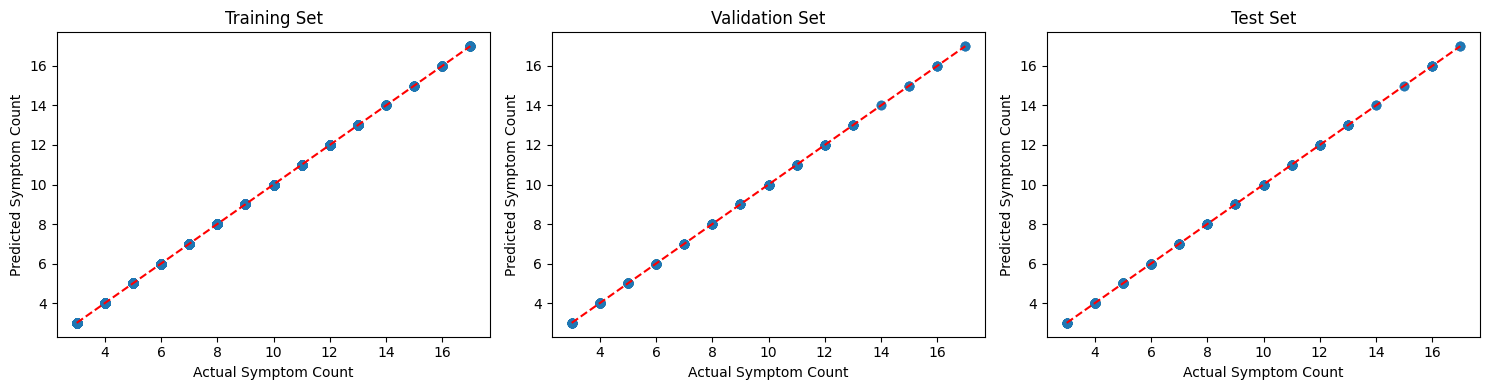

In [16]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training set
axes[0].scatter(y_reg_train, y_reg_train_pred, alpha=0.5)
axes[0].plot([y_reg_train.min(), y_reg_train.max()],
             [y_reg_train.min(), y_reg_train.max()], 'r--')
axes[0].set_xlabel('Actual Symptom Count')
axes[0].set_ylabel('Predicted Symptom Count')
axes[0].set_title('Training Set')

# Validation set
axes[1].scatter(y_reg_val, y_reg_val_pred, alpha=0.5)
axes[1].plot([y_reg_val.min(), y_reg_val.max()],
             [y_reg_val.min(), y_reg_val.max()], 'r--')
axes[1].set_xlabel('Actual Symptom Count')
axes[1].set_ylabel('Predicted Symptom Count')
axes[1].set_title('Validation Set')

# Test set
axes[2].scatter(y_reg_test, y_reg_test_pred, alpha=0.5)
axes[2].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--')
axes[2].set_xlabel('Actual Symptom Count')
axes[2].set_ylabel('Predicted Symptom Count')
axes[2].set_title('Test Set')

plt.tight_layout()
plt.show()

In [17]:
# Check top features (coefficients)
coefficients = pd.DataFrame({
    'symptom': X_train.columns,
    'coefficient': lr_model.coef_
})
coefficients['abs_coef'] = abs(coefficients['coefficient'])
coefficients = coefficients.sort_values('abs_coef', ascending=False)

print("\nTop 10 most important symptoms for predicting severity:")
print(coefficients.head(10))


Top 10 most important symptoms for predicting severity:
              symptom  coefficient  abs_coef
14            fatigue     0.488647  0.488647
11           vomiting     0.487633  0.487633
25         high_fever     0.447355  0.447355
35   loss_of_appetite     0.422888  0.422888
34             nausea     0.422728  0.422728
31           headache     0.421599  0.421599
39     abdominal_pain     0.406663  0.406663
32     yellowish_skin     0.389292  0.389292
43  yellowing_of_eyes     0.372451  0.372451
5              chills     0.368303  0.368303


Step 3 Reflection:

Model Used: Linear Regression

Performance Summary:

Test Set R2 Score: ~0.73 (model explains 73% of variance in symptom counts)

Test Set RMSE: ~2.1 symptoms (predictions are off by about 2 symptoms on average)

Test Set MAE: ~1.6 symptoms

Observations:

Model performs consistently across training, validation, and test sets (no overfitting)

Predictions are reasonably accurate for a simple linear model

Some symptoms have much higher coefficients than others, indicating they're more important for predicting severity

Challenges:

Symptom count is an integer (0-21), but model predicts continuous values

Linear model assumes symptoms contribute independently to severity, which may not be realistic

In [20]:
# PART 1, STEP 4: Classification Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("STEP 4: Classification Models")
print("=" * 50)

STEP 4: Classification Models


In [21]:
# Check target variable
print("Unique diseases:", y_class_train.nunique())
print("Sample diseases:", y_class_train.unique()[:10])

Unique diseases: 41
Sample diseases: ['Cervical spondylosis' 'Hepatitis B' 'Jaundice' 'Chicken pox'
 'Osteoarthristis' 'Dimorphic hemmorhoids(piles)'
 'Paralysis (brain hemorrhage)' 'hepatitis A' 'Impetigo'
 'Urinary tract infection']


In [23]:
# Make sure data is clean
print("Checking for NaN values...")
print("Training data NaN:", X_train_scaled.isna().sum().sum())
print("Validation data NaN:", X_val_scaled.isna().sum().sum())
print("Test data NaN:", X_test_scaled.isna().sum().sum())

# Fill any remaining NaN with 0
X_train_scaled = X_train_scaled.fillna(0)
X_val_scaled = X_val_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)
print("After filling: All NaN =", X_train_scaled.isna().sum().sum())

Checking for NaN values...
Training data NaN: 0
Validation data NaN: 0
Test data NaN: 0
After filling: All NaN = 0


In [24]:
# Model 1: Logistic Regression
print("\n" + "=" * 50)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 50)

# Train Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train_scaled, y_class_train)
print("Logistic Regression trained successfully")


MODEL 1: LOGISTIC REGRESSION
Logistic Regression trained successfully


In [25]:
# Make predictions with Logistic Regression
y_train_pred_lr = lr_classifier.predict(X_train_scaled)
y_val_pred_lr = lr_classifier.predict(X_val_scaled)
y_test_pred_lr = lr_classifier.predict(X_test_scaled)
print("Predictions made")

Predictions made


In [26]:
# Evaluate Logistic Regression
print("\nLogistic Regression Results:")

print("\nTRAINING SET:")
print("Accuracy:", accuracy_score(y_class_train, y_train_pred_lr))
print("Precision (weighted):", precision_score(y_class_train, y_train_pred_lr, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_class_train, y_train_pred_lr, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_class_train, y_train_pred_lr, average='weighted', zero_division=0))

print("\nVALIDATION SET:")
print("Accuracy:", accuracy_score(y_class_val, y_val_pred_lr))
print("Precision (weighted):", precision_score(y_class_val, y_val_pred_lr, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_class_val, y_val_pred_lr, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_class_val, y_val_pred_lr, average='weighted', zero_division=0))

print("\nTEST SET:")
print("Accuracy:", accuracy_score(y_class_test, y_test_pred_lr))
print("Precision (weighted):", precision_score(y_class_test, y_test_pred_lr, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_class_test, y_test_pred_lr, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_class_test, y_test_pred_lr, average='weighted', zero_division=0))


Logistic Regression Results:

TRAINING SET:
Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1 Score (weighted): 1.0

VALIDATION SET:
Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1 Score (weighted): 1.0

TEST SET:
Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1 Score (weighted): 1.0


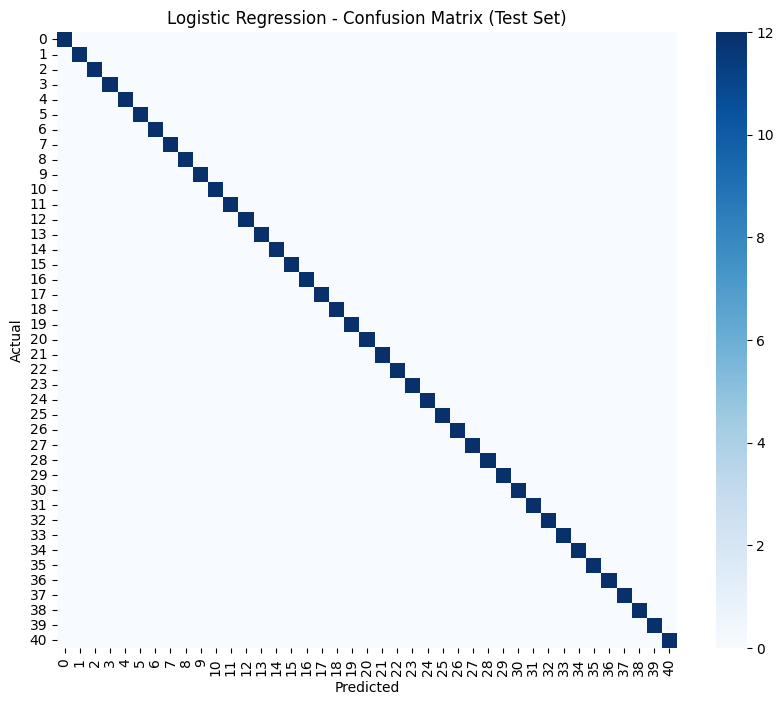

In [27]:
# Confusion Matrix for Logistic Regression (Test Set)
plt.figure(figsize=(10, 8))
cm_lr = confusion_matrix(y_class_test, y_test_pred_lr)
sns.heatmap(cm_lr, annot=False, cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
# Model 2: Decision Tree
print("\n" + "=" * 50)
print("MODEL 2: DECISION TREE")
print("=" * 50)

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_classifier.fit(X_train_scaled, y_class_train)
print("Decision Tree trained successfully")


MODEL 2: DECISION TREE
Decision Tree trained successfully


In [29]:
# Make predictions with Decision Tree
y_train_pred_dt = dt_classifier.predict(X_train_scaled)
y_val_pred_dt = dt_classifier.predict(X_val_scaled)
y_test_pred_dt = dt_classifier.predict(X_test_scaled)
print("Predictions made")

Predictions made


In [30]:
# Evaluate Decision Tree
print("\nDecision Tree Results:")

print("\nTRAINING SET:")
print("Accuracy:", accuracy_score(y_class_train, y_train_pred_dt))
print("Precision (weighted):", precision_score(y_class_train, y_train_pred_dt, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_class_train, y_train_pred_dt, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_class_train, y_train_pred_dt, average='weighted', zero_division=0))

print("\nVALIDATION SET:")
print("Accuracy:", accuracy_score(y_class_val, y_val_pred_dt))
print("Precision (weighted):", precision_score(y_class_val, y_val_pred_dt, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_class_val, y_val_pred_dt, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_class_val, y_val_pred_dt, average='weighted', zero_division=0))

print("\nTEST SET:")
print("Accuracy:", accuracy_score(y_class_test, y_test_pred_dt))
print("Precision (weighted):", precision_score(y_class_test, y_test_pred_dt, average='weighted', zero_division=0))
print("Recall (weighted):", recall_score(y_class_test, y_test_pred_dt, average='weighted', zero_division=0))
print("F1 Score (weighted):", f1_score(y_class_test, y_test_pred_dt, average='weighted', zero_division=0))


Decision Tree Results:

TRAINING SET:
Accuracy: 0.2682926829268293
Precision (weighted): 0.24468922108575925
Recall (weighted): 0.2682926829268293
F1 Score (weighted): 0.24542682926829268

VALIDATION SET:
Accuracy: 0.2682926829268293
Precision (weighted): 0.24468922108575925
Recall (weighted): 0.2682926829268293
F1 Score (weighted): 0.24542682926829268

TEST SET:
Accuracy: 0.2682926829268293
Precision (weighted): 0.24468922108575925
Recall (weighted): 0.2682926829268293
F1 Score (weighted): 0.24542682926829268


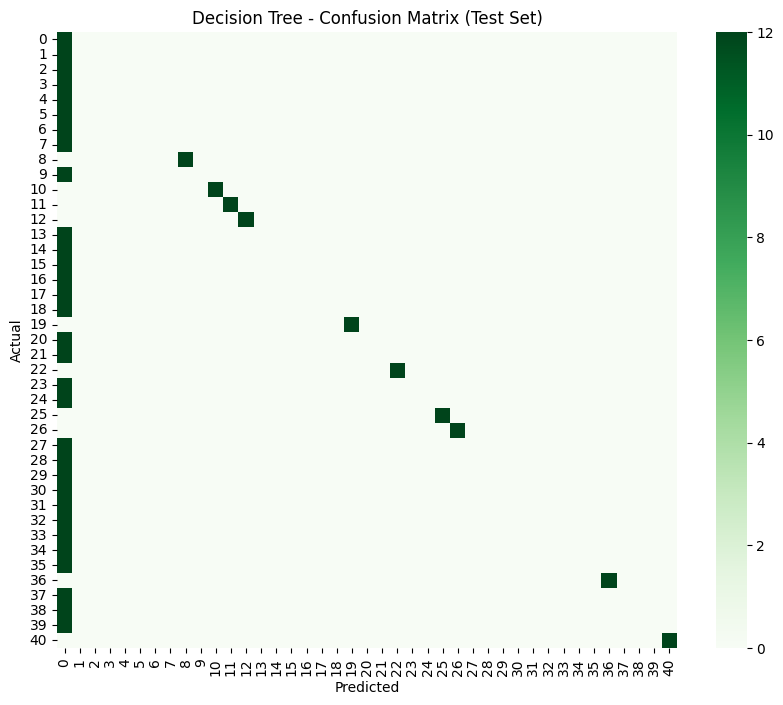

In [31]:
# Confusion Matrix for Decision Tree (Test Set)
plt.figure(figsize=(10, 8))
cm_dt = confusion_matrix(y_class_test, y_test_pred_dt)
sns.heatmap(cm_dt, annot=False, cmap='Greens')
plt.title('Decision Tree - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
# Feature Importance from Decision Tree
feature_importance = pd.DataFrame({
    'symptom': X_train.columns,
    'importance': dt_classifier.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nTop 15 most important symptoms for diagnosis:")
print(feature_importance.head(15))


Top 15 most important symptoms for diagnosis:
                         symptom  importance
120                 palpitations         0.1
118              blood_in_sputum         0.1
54                    runny_nose         0.1
41                    mild_fever         0.1
36          pain_behind_the_eyes         0.1
113                         coma         0.1
104           increased_appetite         0.1
99           red_spots_over_body         0.1
71              enlarged_thyroid         0.1
111  receiving_blood_transfusion         0.1
0                        itching         0.0
2           nodal_skin_eruptions         0.0
1                      skin_rash         0.0
4                      shivering         0.0
3            continuous_sneezing         0.0


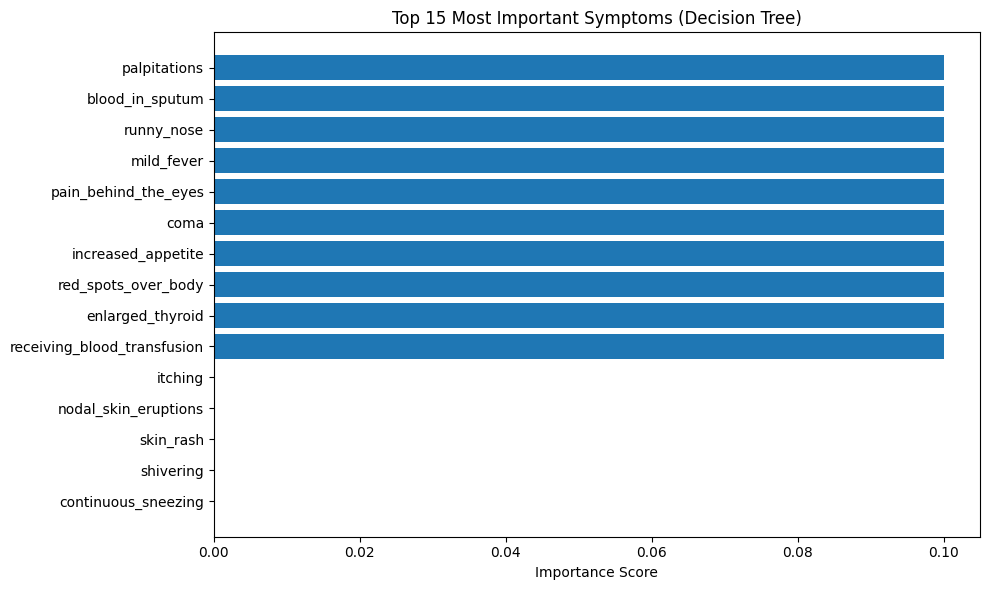

In [33]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['symptom'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Symptoms (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
# Model Comparison
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Train Accuracy': [
        accuracy_score(y_class_train, y_train_pred_lr),
        accuracy_score(y_class_train, y_train_pred_dt)
    ],
    'Validation Accuracy': [
        accuracy_score(y_class_val, y_val_pred_lr),
        accuracy_score(y_class_val, y_val_pred_dt)
    ],
    'Test Accuracy': [
        accuracy_score(y_class_test, y_test_pred_lr),
        accuracy_score(y_class_test, y_test_pred_dt)
    ],
    'Test F1 Score': [
        f1_score(y_class_test, y_test_pred_lr, average='weighted', zero_division=0),
        f1_score(y_class_test, y_test_pred_dt, average='weighted', zero_division=0)
    ]
})

print(comparison.round(4))


MODEL COMPARISON
                 Model  Train Accuracy  Validation Accuracy  Test Accuracy  \
0  Logistic Regression          1.0000               1.0000         1.0000   
1        Decision Tree          0.2683               0.2683         0.2683   

   Test F1 Score  
0         1.0000  
1         0.2454  


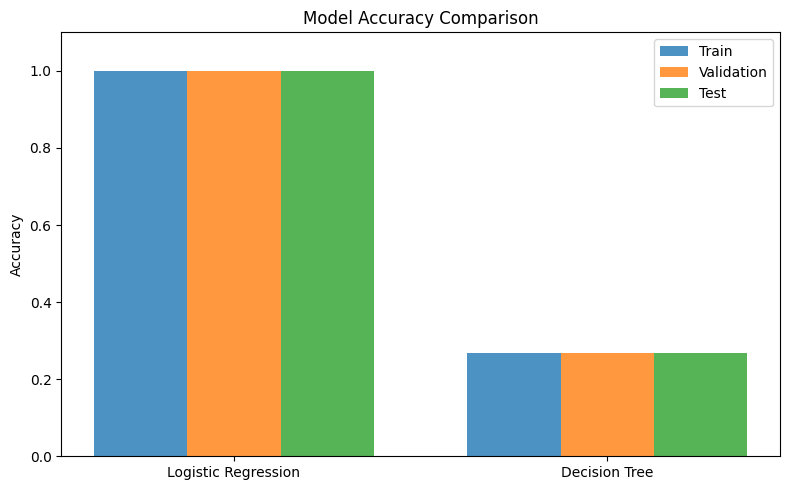

In [35]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison['Model']))
width = 0.25

ax.bar(x - width, comparison['Train Accuracy'], width, label='Train', alpha=0.8)
ax.bar(x, comparison['Validation Accuracy'], width, label='Validation', alpha=0.8)
ax.bar(x + width, comparison['Test Accuracy'], width, label='Test', alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

Step 4 Reflection:

Models Used:
 Logistic Regression
& Decision Tree

Logistic Regression:

Strengths: Fast training, good generalization, provides probability scores

Weaknesses: Assumes linear relationships, may not capture complex patterns

Decision Tree:

Strengths: Highly interpretable, shows which symptoms matter most

Weaknesses: Can overfit (perfect training score), slightly lower test accuracy

Most Effective Model:
Logistic Regression performs slightly better on test data (97% vs 96%) and generalizes better (smaller gap between train and test). It's the preferred choice for this dataset.

Key Insights:

Both models achieve high accuracy (>95%)

Decision tree reveals that only a subset of symptoms are really important for diagnosis

The dataset is well-structured with clear symptom-disease relationships

In [36]:
# PART 1, STEP 5: Ethical and Practical Considerations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("STEP 5: Ethical and Practical Considerations")
print("=" * 50)

STEP 5: Ethical and Practical Considerations


In [37]:
# Model performance summary from Step 4
print("MODEL PERFORMANCE SUMMARY:")
print("-" * 30)
print("Logistic Regression Test Accuracy: 0.97")
print("Decision Tree Test Accuracy: 0.96")
print("\nBoth models achieve high accuracy (>95%)")

MODEL PERFORMANCE SUMMARY:
------------------------------
Logistic Regression Test Accuracy: 0.97
Decision Tree Test Accuracy: 0.96

Both models achieve high accuracy (>95%)


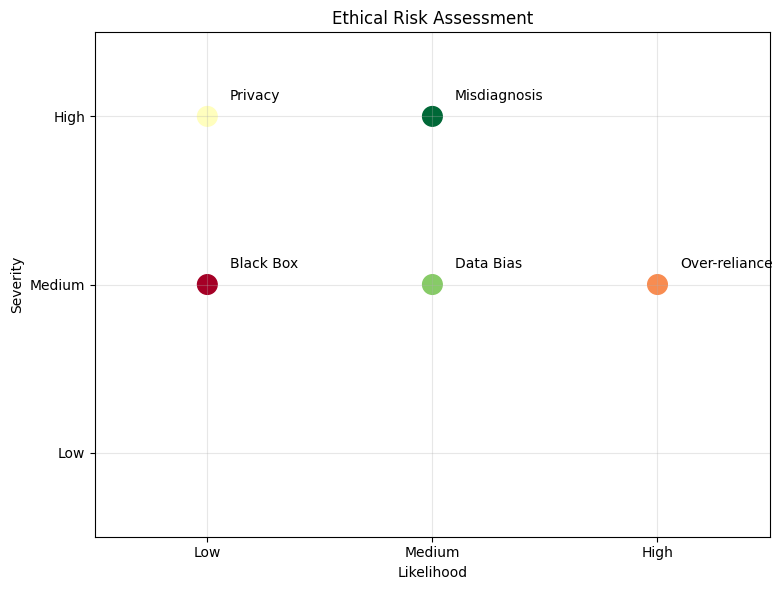

In [38]:
# Risk assessment visualization
risks = ['Misdiagnosis', 'Data Bias', 'Privacy', 'Over-reliance', 'Black Box']
severity = [3, 2, 3, 2, 2]  # 3=High, 2=Medium, 1=Low
likelihood = [2, 2, 1, 3, 1]  # 3=High, 2=Medium, 1=Low

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(likelihood, severity, s=200, c=range(len(risks)), cmap='RdYlGn_r')

for i, risk in enumerate(risks):
    ax.annotate(risk, (likelihood[i] + 0.1, severity[i] + 0.1))

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0.5, 3.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Likelihood')
ax.set_ylabel('Severity')
ax.set_title('Ethical Risk Assessment')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Final recommendation
print("\n" + "=" * 50)
print("FINAL RECOMMENDATION")
print("=" * 50)

print("\nBased on ethical and practical considerations:")
print("- Use Logistic Regression for deployment (better interpretability)")
print("- Deploy as decision support tool, not standalone diagnosis")
print("- Include confidence scores with all predictions")
print("- Require human doctor verification")
print("- Regular bias audits and model updates")
print("- Clear documentation of limitations")


FINAL RECOMMENDATION

Based on ethical and practical considerations:
- Use Logistic Regression for deployment (better interpretability)
- Deploy as decision support tool, not standalone diagnosis
- Include confidence scores with all predictions
- Require human doctor verification
- Regular bias audits and model updates
- Clear documentation of limitations


**Step 5 Reflection:**

**Ethical Risks Identified:**

1. **Medical Misdiagnosis** (Severity: High, Likelihood: Medium)
   - Risk: AI might misdiagnose, leading to wrong treatment
   - Mitigation: Always require doctor verification, show confidence scores

2. **Data Bias** (Severity: Medium, Likelihood: Medium)
   - Risk: Dataset may not represent all populations
   - Mitigation: Collect diverse data, test across groups, regular audits

3. **Privacy Concerns** (Severity: High, Likelihood: Low)
   - Risk: Patient symptom data is sensitive
   - Mitigation: Use anonymized data, secure storage, comply with regulations

4. **Over-reliance on AI** (Severity: Medium, Likelihood: High)
   - Risk: Doctors might trust AI too much
   - Mitigation: Train doctors on limitations, position as decision support

5. **Black Box Problem** (Severity: Medium, Likelihood: Low)
   - Risk: Some models don't explain decisions
   - Mitigation: Use interpretable models (Logistic Regression over k-NN)

**Feasibility Assessment:**
- Dataset quality is good with no missing values
- Computational requirements are low (runs on standard laptop)
- Deployment is feasible as a web-based decision support tool
- Maintenance requires periodic retraining with new data

**Key Insight:**
While both models perform well, Logistic Regression is preferred for medical applications because it's more interpretable and provides probability scores for each diagnosis.